# UGRID River Channel — Tidal Estuary Analysis

This notebook demonstrates pyramids' UGRID capabilities on a **synthetic
river channel mesh** that simulates a meandering tidal estuary. The mesh
was created using `UgridDataset.create_from_arrays()` and saved as a
UGRID-compliant NetCDF file.

The dataset contains:
- **320 nodes**, **273 quad faces** in a structured-like channel grid
- **Bathymetry** (face-centered) — parabolic cross-section, deeper in the center
- **Water level** (face-centered, 6 hourly time steps) — tidal signal propagating upstream
- **Velocity** (node-centered) — parabolic profile, fastest in the center
- CRS: **EPSG:32631** (UTM zone 31N)

We'll cover:
1. Reading & inspecting the mesh
2. Plotting bathymetry and velocity
3. Temporal analysis — tidal propagation
4. Spatial subsetting — isolating the meander bend
5. Mesh-to-raster conversion
6. Vector export to GeoDataFrame
7. Animation of tidal water levels

**Data source**: Synthetic, generated with pyramids. The mesh topology
follows [UGRID-1.0 conventions](https://ugrid-conventions.github.io/ugrid-conventions/).
Similar meshes are produced by models like [FVCOM](http://fvcom.smast.umassd.edu/),
[SCHISM](https://schism-dev.github.io/schism/), and
[ADCIRC](https://adcirc.org/).

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pyramids.netcdf.ugrid import (
    UgridDataset,
    Mesh2d,
    MeshSpatialIndex,
)

## 1. Reading & Inspecting the Mesh

In [ ]:
ds = UgridDataset.read_file("../../examples/data/river_channel_ugrid.nc")
print(ds)

In [79]:
mesh = ds.mesh

print(f"Nodes:       {mesh.n_node}")
print(f"Faces:       {mesh.n_face}")
print(f"Edges:       {mesh.n_edge}")
print(f"Bounds:      x=[{mesh.bounds[0]:.0f}, {mesh.bounds[2]:.0f}] m")
print(f"             y=[{mesh.bounds[1]:.0f}, {mesh.bounds[3]:.0f}] m")
print(f"EPSG:        {ds.epsg}")
print(f"Variables:   {ds.data_variable_names}")
print(f"Conventions: {ds.global_attributes.get('Conventions', 'N/A')}")
print()

# Inspect each variable
for name in ds.data_variable_names:
    var = ds[name]
    print(f"{name}:")
    print(f"  location={var.location}, shape={var.shape}, has_time={var.has_time}")

Nodes:       320
Faces:       273
Edges:       0
Bounds:      x=[-61, 5061] m
             y=[-450, 450] m
EPSG:        32631
Variables:   ['bathymetry', 'water_level', 'velocity']
Conventions: CF-1.8 UGRID-1.0

bathymetry:
  location=face, shape=(273,), has_time=False
water_level:
  location=face, shape=(6, 273), has_time=True
velocity:
  location=node, shape=(320,), has_time=False


In [80]:
# Connectivity: how many nodes per face?
fnc = mesh.face_node_connectivity
counts = fnc.nodes_per_element()
print(f"Nodes per face: min={counts.min()}, max={counts.max()}")
print(f"All quads? {bool(np.all(counts == 4))}")
print(f"Fan triangles: {mesh.fan_triangles.shape[0]} triangles from {mesh.n_face} faces")

# Face areas
areas = mesh.face_areas
print(f"Face areas: min={areas.min():.0f}, max={areas.max():.0f}, mean={areas.mean():.0f} m²")

Nodes per face: min=4, max=4
All quads? True
Fan triangles: 546 triangles from 273 faces
Face areas: min=8538, max=9774, mean=9299 m²


## 2. Plotting Bathymetry and Velocity

Plotting delegates to `cleopatra.MeshGlyph`. Face data uses
`tripcolor`, node data uses `tricontourf`.

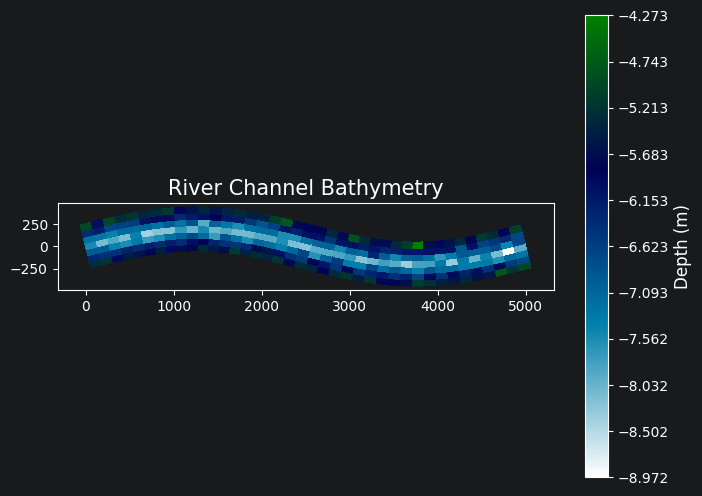

In [81]:
# Bathymetry (face-centered): deeper blue = deeper water
glyph = ds.plot(
    "bathymetry",
    cmap="ocean_r",
    title="River Channel Bathymetry",
    cbar_label="Depth (m)",
)
plt.show()

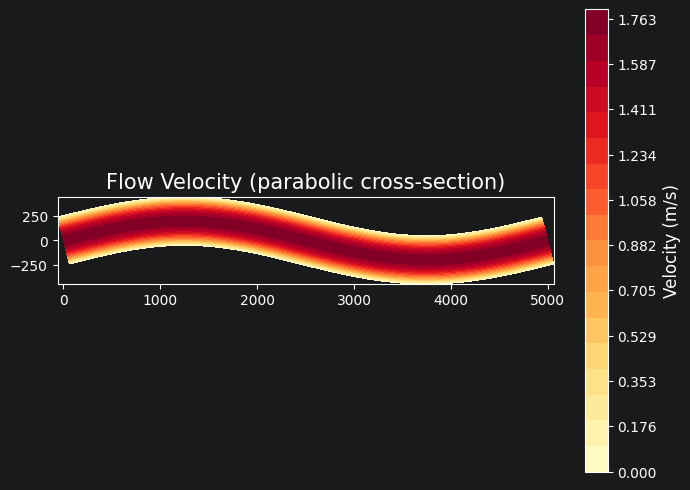

In [82]:
# Velocity (node-centered): smooth contour interpolation
glyph = ds.plot(
    "velocity",
    cmap="YlOrRd",
    title="Flow Velocity (parabolic cross-section)",
    cbar_label="Velocity (m/s)",
)
plt.show()

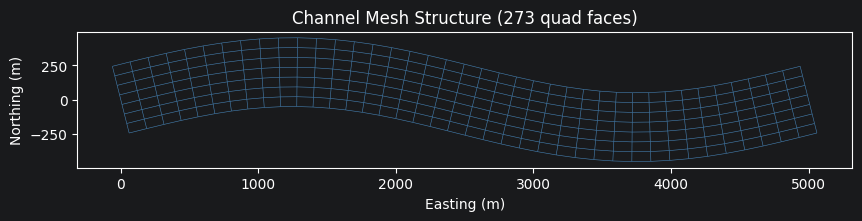

In [83]:
# Wireframe: mesh structure
glyph = ds.plot_outline(color="steelblue", linewidth=0.4)
plt.title("Channel Mesh Structure (273 quad faces)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

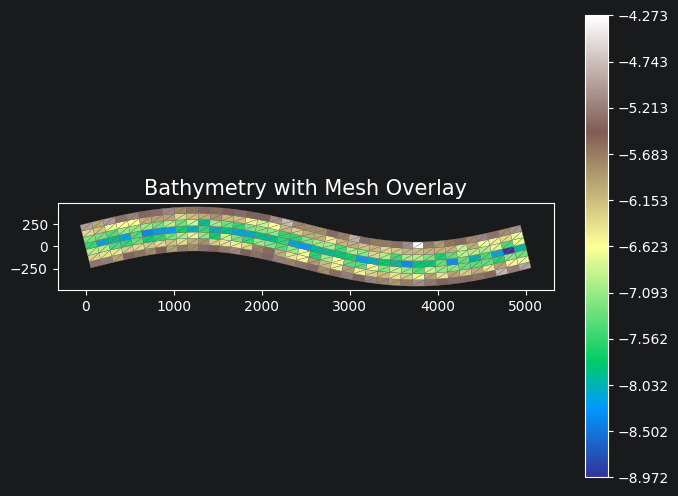

In [84]:
# Overlay: bathymetry with mesh edges visible
glyph = ds.plot(
    "bathymetry",
    cmap="terrain",
    edgecolor="gray",
    title="Bathymetry with Mesh Overlay",
)
plt.show()

## 3. Temporal Analysis — Tidal Propagation

The `water_level` variable has 6 hourly time steps showing
a tidal wave propagating upstream.

In [85]:
wl = ds["water_level"]
print(f"Shape: {wl.shape}  (time_steps x faces)")
print(f"Has time: {wl.has_time}")
print(f"Time steps: {wl.n_time_steps}")
print(f"Range: [{wl.data.min():.2f}, {wl.data.max():.2f}] m")

Shape: (6, 273)  (time_steps x faces)
Has time: True
Time steps: 6
Range: [-1.48, 1.42] m


In [86]:
# Select individual time steps
ds_t0 = ds.sel_time(0)
ds_t3 = ds.sel_time(3)
print(f"Time step 0: water_level shape = {ds_t0['water_level'].shape}")
print(f"Time step 3: water_level shape = {ds_t3['water_level'].shape}")

Time step 0: water_level shape = (273,)
Time step 3: water_level shape = (273,)


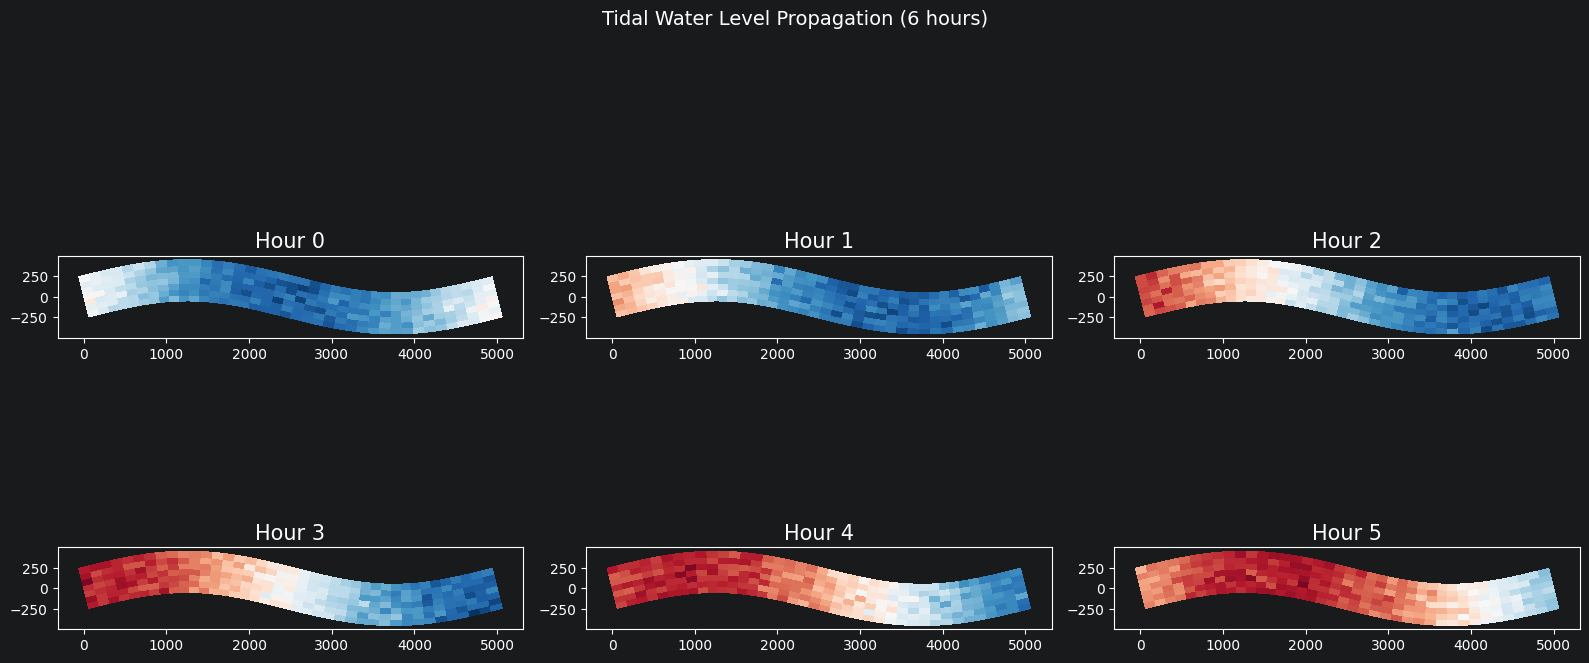

In [87]:
# Plot all 6 time steps side by side
from pyramids.netcdf.ugrid.plot import plot_mesh_data

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for t, ax in enumerate(axes.flat):
    glyph = plot_mesh_data(
        ds.mesh,
        wl.data[t],
        location="face",
        ax=ax,
        cmap="RdBu_r",
        vmin=-1.5,
        vmax=1.5,
        colorbar=False,
        title=f"Hour {t}",
    )

fig.suptitle("Tidal Water Level Propagation (6 hours)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

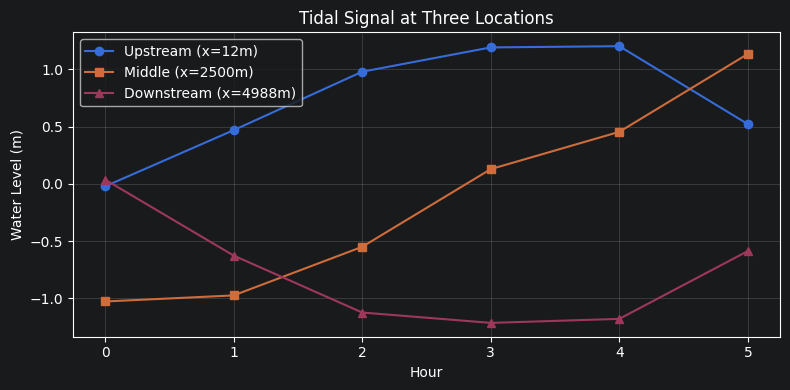

In [88]:
# Time series at a specific face
cx, cy = mesh.face_centroids
# Pick 3 faces: upstream, middle, downstream
upstream_face = np.argmin(cx)  # smallest x = upstream
downstream_face = np.argmax(cx)  # largest x = downstream
middle_face = np.argmin(np.abs(cx - cx.mean()))  # center

fig, ax = plt.subplots(figsize=(8, 4))
hours = np.arange(wl.n_time_steps)
ax.plot(hours, wl.data[:, upstream_face], "o-", label=f"Upstream (x={cx[upstream_face]:.0f}m)")
ax.plot(hours, wl.data[:, middle_face], "s-", label=f"Middle (x={cx[middle_face]:.0f}m)")
ax.plot(hours, wl.data[:, downstream_face], "^-", label=f"Downstream (x={cx[downstream_face]:.0f}m)")
ax.set_xlabel("Hour")
ax.set_ylabel("Water Level (m)")
ax.set_title("Tidal Signal at Three Locations")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Spatial Subsetting — Isolating the Meander Bend

Original: 273 faces
Bend:     133 faces


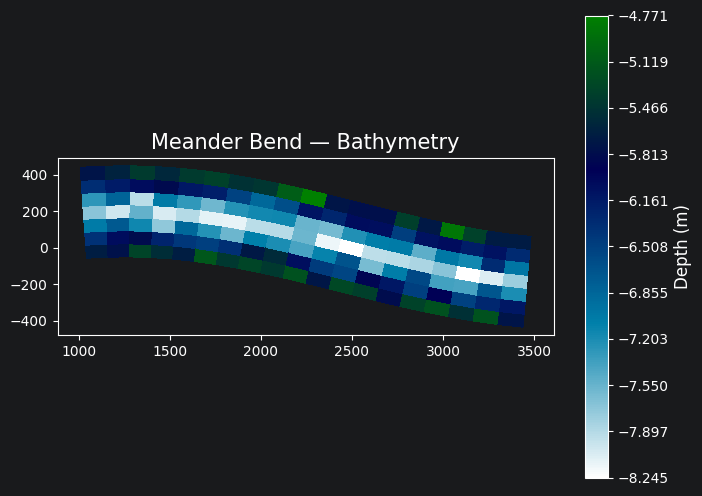

In [89]:
# Bounding box subset: extract the meander bend (roughly x=1000-3500)
bend = ds.subset_by_bounds(1000, -500, 3500, 500)
print(f"Original: {ds.n_face} faces")
print(f"Bend:     {bend.n_face} faces")

glyph = bend.plot(
    "bathymetry",
    cmap="ocean_r",
    title="Meander Bend — Bathymetry",
    cbar_label="Depth (m)",
)
plt.show()

Clipped to circle: 56 faces around deepest point


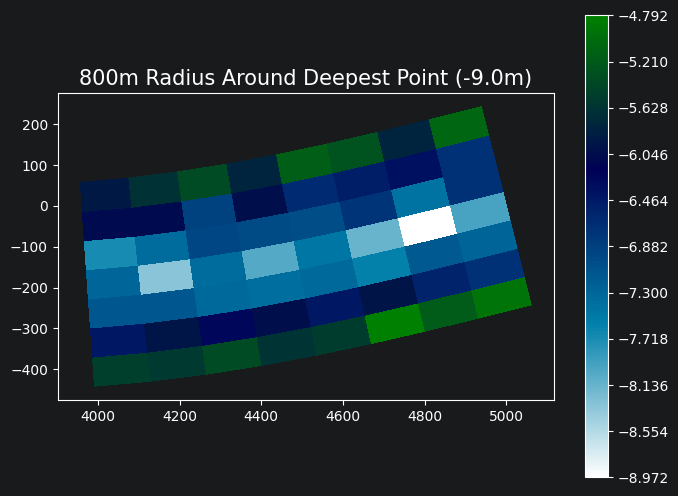

In [90]:
# Polygon clipping: circular region around the deepest part
from shapely.geometry import Point

deepest_face = np.argmin(ds["bathymetry"].data)
deep_x, deep_y = cx[deepest_face], cy[deepest_face]
clip_region = Point(deep_x, deep_y).buffer(800)  # 800m radius circle

clipped = ds.clip(clip_region, touch=True)
print(f"Clipped to circle: {clipped.n_face} faces around deepest point")

glyph = clipped.plot(
    "bathymetry",
    cmap="ocean_r",
    title=f"800m Radius Around Deepest Point ({ds['bathymetry'].data[deepest_face]:.1f}m)",
)
plt.show()

## 5. Mesh-to-Raster Conversion

`to_dataset()` interpolates mesh data onto a regular grid,
producing a standard pyramids `Dataset` for raster operations.

In [91]:
# Nearest-neighbor rasterization
raster_nn = ds.to_dataset("bathymetry", cell_size=50.0, method="nearest")
print(f"Nearest: {raster_nn.rows} x {raster_nn.columns}, cell_size={raster_nn.cell_size}m")

# Linear interpolation (smoother)
raster_lin = ds.to_dataset("velocity", cell_size=50.0, method="linear")
print(f"Linear:  {raster_lin.rows} x {raster_lin.columns}")

Nearest: 18 x 103, cell_size=50.0m
Linear:  18 x 103


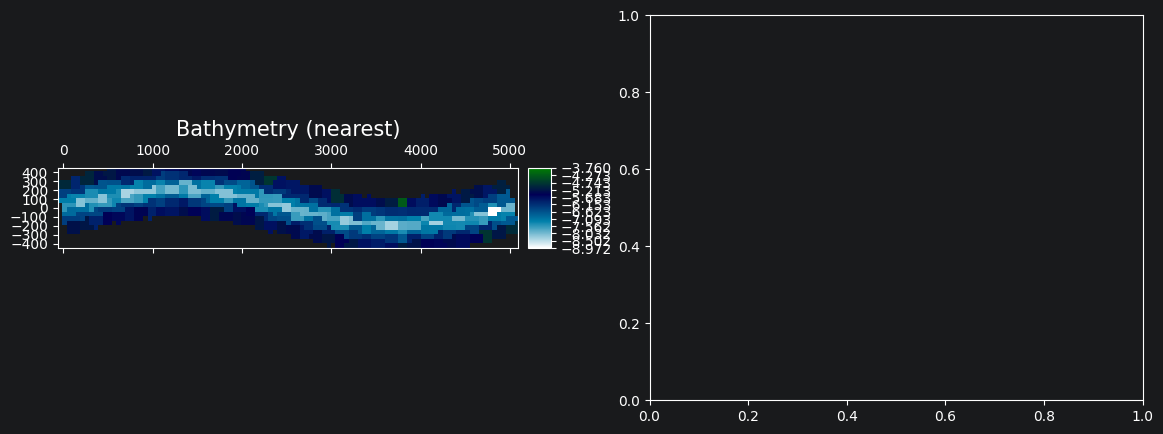

<Figure size 640x480 with 0 Axes>

In [92]:
# Compare nearest vs linear on subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
raster_nn.plot(cmap="ocean_r", title="Bathymetry (nearest)", ax=axes[0], fig=fig)
raster_lin.plot(cmap="YlOrRd", title="Velocity (linear)", ax=axes[1], fig=fig)

plt.tight_layout()
plt.show()

In [93]:
# Save to GeoTIFF for use in GIS
raster_nn.to_file("river_bathymetry.tif")
print("Saved river_bathymetry.tif")

Saved river_bathymetry.tif


## 6. Vector Export to GeoDataFrame

In [94]:
# Export faces as polygons with bathymetry data
gdf = bend.to_geodataframe("bathymetry", location="face")
print(f"GeoDataFrame: {len(gdf)} polygons")
print(f"Columns: {list(gdf.columns)}")
print(f"CRS: {gdf.crs}")
gdf.head()

GeoDataFrame: 133 polygons
Columns: ['bathymetry', 'geometry']
CRS: PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]


,bathymetry,geometry
0,-5.680337,"POLYGON ((1043.079 -57.287, 1038.097 13.967, 1..."
1,-6.378478,"POLYGON ((1038.097 13.967, 1033.115 85.222, 11..."
2,-7.043478,"POLYGON ((1033.115 85.222, 1028.132 156.476, 1..."
3,-7.707336,"POLYGON ((1028.132 156.476, 1023.15 227.731, 1..."
4,-7.286609,"POLYGON ((1023.15 227.731, 1018.167 298.986, 1..."


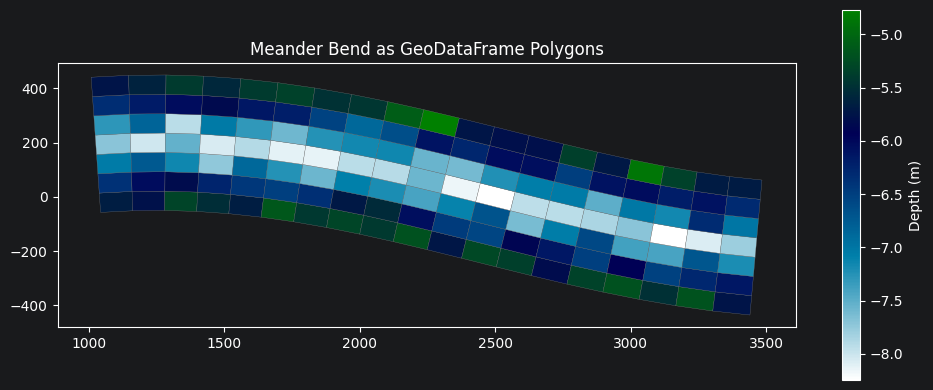

In [95]:
# Plot with geopandas
fig, ax = plt.subplots(figsize=(10, 4))
gdf.plot(
    column="bathymetry", cmap="ocean_r", ax=ax,
    legend=True, edgecolor="gray", linewidth=0.2,
    legend_kwds={"label": "Depth (m)"},
)
ax.set_title("Meander Bend as GeoDataFrame Polygons")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Node GeoDataFrame: 160 points


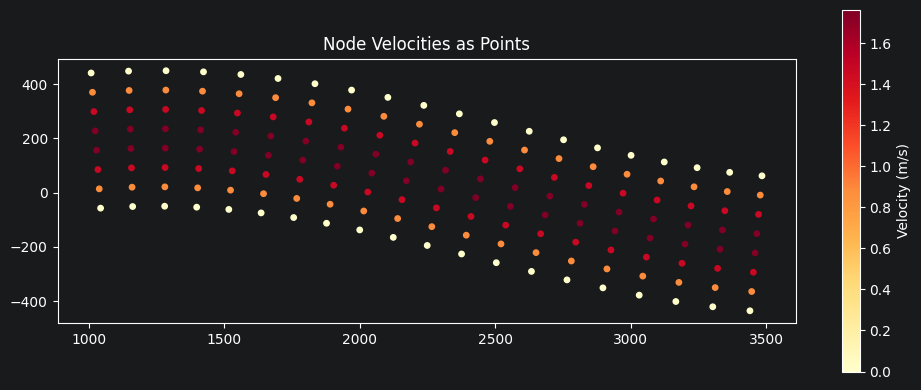

In [96]:
# Nodes as points with velocity
gdf_nodes = bend.to_geodataframe("velocity", location="node")
print(f"Node GeoDataFrame: {len(gdf_nodes)} points")

fig, ax = plt.subplots(figsize=(10, 4))
gdf_nodes.plot(
    column="velocity", cmap="YlOrRd", ax=ax,
    markersize=15, legend=True,
    legend_kwds={"label": "Velocity (m/s)"},
)
ax.set_title("Node Velocities as Points")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Animation of Tidal Water Levels

Using cleopatra's `MeshGlyph.animate()` to create a tidal cycle animation.

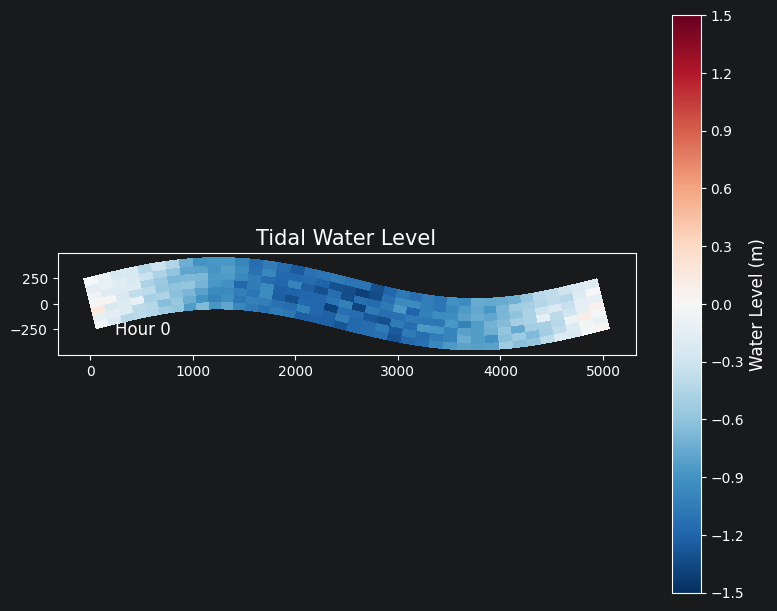

In [97]:
from pyramids.netcdf.ugrid.plot import _mesh_to_glyph

glyph = _mesh_to_glyph(ds.mesh)
anim = glyph.animate(
    wl.data,
    time=[f"Hour {t}" for t in range(wl.n_time_steps)],
    location="face",
    cmap="RdBu_r",
    vmin=-1.5,
    vmax=1.5,
    interval=800,
    title="Tidal Water Level",
    cbar_label="Water Level (m)",
)

from IPython.display import HTML
HTML(anim.to_jshtml())

## Summary

This notebook demonstrated a complete UGRID workflow on a synthetic
river channel mesh:

| Step | What we did |
|------|------------|
| Read | `UgridDataset.read_file()` — parsed UGRID topology |
| Inspect | Explored nodes, faces, connectivity, areas |
| Plot | Bathymetry (face), velocity (node), wireframe |
| Temporal | 6-hour tidal propagation, time-series at 3 locations |
| Subset | Bounding box + circular polygon clipping |
| Rasterize | Nearest + linear interpolation to GeoTIFF |
| Vector | Face polygons + node points as GeoDataFrame |
| Animate | Tidal water level animation via MeshGlyph |

In [98]:
# Cleanup
for f in [Path("river_bathymetry.tif")]:
    try:
        f.unlink(missing_ok=True)
        print(f"Cleaned up {f}")
    except OSError:
        pass